## GPR on WeatherBench Data - z500
Apply GP regression baseline (using exact GP to train on monthly data)

In [1]:
# Check GPU
!nvidia-smi

%load_ext autoreload
%autoreload 2

Mon Apr  7 14:58:31 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.12             Driver Version: 535.104.12   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          Off | 00000000:1B:00.0 Off |                    0 |
| N/A   58C    P0              71W / 300W |  32451MiB / 81920MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import time
import gc
from tqdm.notebook import tqdm

import torch
import gpytorch

from GPyTorch.GPRs.model import ExactGP
from GPyTorch.GPRs.utils import extrapolate_seasonal
from GPyTorch.GPRs.process_data import create_data
from GPyTorch.GPRs.plot import *

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Processing

Loading the data

In [3]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017', '2017')).isel(lat=slice(18, 32), lon=slice(43, 50))['z']
z500_test = z500.sel(time=slice('2018', '2018.1.7')).isel(lat=slice(18, 32), lon=slice(43, 50))['z']

data_detrend = xr.open_dataset('data/5.625deg/detrended/z500/detrended_dataset.nc')
# Extrapolate seasonal component for a week
forecast_steps = len(z500_test.time)
seasonal_forecast = extrapolate_seasonal(data_detrend, forecast_steps)

In [4]:
data_detrend = data_detrend.sel(time=slice('2017', '2017')).isel(lat=slice(18, 32), lon=slice(43, 50))
z500_recon = data_detrend.seasonal + data_detrend.resid
z500_train_resid = data_detrend.resid
z500_train_seasonal = data_detrend.seasonal

seasonal_forecast = seasonal_forecast.isel(lat=slice(18, 32), lon=slice(43, 50))

In [5]:
# Check if data compatible
np.sum(z500_recon.values - z500_train.values)

np.float64(0.0)

In [6]:
#data_mean = z500_train.mean().load()
#data_std = z500_train.std().load()

# Normalize datasets
#data_train = (z500_train - data_mean) / data_std
#data_test = (z500_test - data_mean) / data_std

In [7]:
# If use residuals
data_mean = z500_train_resid.mean().load()
data_std = z500_train_resid.std().load()

# Normalize datasets
data_train = (z500_train_resid - data_mean) / data_std
data_test = (z500_test - seasonal_forecast - data_mean) / data_std

## Defining the Kernel

We use a separable kernel in space and time:
$$K(x,y,z,t) = K_{\text{space}}(x,y,z) \times K_{\text{time}}(t),$$
where $K_{\text{space}}(x,y,z) = \sum_n K_{n\text{, Matern}}(x,y,z)$ and $K_{\text{time}}(t) = \sum_n K_{n\text{, Periodic}}(t)$.

In [8]:
# Define the GP regression kernel, separable in space and time
### First define the spatial kernel 
spatial_lengths = [0.08, 0.25, 0.5]

# Smoothness param of matern kernel set to 3/2
matern_spatial_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_1.lengthscale = torch.tensor(spatial_lengths[0]).to(device)
matern_spatial_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_2.lengthscale = torch.tensor(spatial_lengths[1]).to(device)
matern_spatial_3 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_3.lengthscale = torch.tensor(spatial_lengths[2]).to(device)

#matern_spatial_1.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(spatial_lengths[0], spatial_lengths[0]/3), "lengthscale")
#matern_spatial_2.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(spatial_lengths[1], spatial_lengths[1]/3), "lengthscale")

spatial_kernel = matern_spatial_1 + matern_spatial_2 + matern_spatial_3

In [9]:
### For temporal kernel
period_lengths = [24, 24*30*3, 24*30*12]

time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Daily    
time_kernel1.period_length = torch.tensor(period_lengths[0]).to(device)
time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) 
time_kernel2.period_length = torch.tensor(period_lengths[1]).to(device)
time_kernel3 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) 
time_kernel3.period_length = torch.tensor(period_lengths[2]).to(device)

#time_kernel1.register_prior("period_length_prior", gpytorch.priors.NormalPrior(period_lengths[0], period_lengths[0]/3), "period_length")
#time_kernel2.register_prior("period_length_prior", gpytorch.priors.NormalPrior(period_lengths[1], period_lengths[1]/3), "period_length")

matern_time_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[3]).to(device)
#matern_time_1.lengthscale = torch.tensor(40).to(device)
#matern_time_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[3]).to(device)
#matern_time_2.lengthscale = torch.tensor(24*7).to(device)

time_kernel = matern_time_1 + time_kernel1 + time_kernel2 + time_kernel3

In [10]:
# Assembling the Kernel

# If wrap scaling only to the spatial kernel
# spatial_kernel = gpytorch.kernels.ScaleKernel(spatial_kernel).to(device)
# kernel = spatial_kernel * time_kernel

# If wrap scaling to the whole kernel
kernel = gpytorch.kernels.ScaleKernel(spatial_kernel * time_kernel).to(device)

## Training and Evaluation

In [11]:
def train_gp(lead_time_h, data_train, data_test, space_subsample=1, time_subsample=1, frac=0.01, epochs=5000, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data
    X_train, Y_train = create_data(data_train, data_test, lead_time_h, space_subsample=space_subsample, 
                                   time_subsample=time_subsample)
    X_train = X_train.to(device)
    Y_train = Y_train.to(device)
    #X_train = X_train.view(-1, 4)

    # Random Sampling 
    N = X_train.shape[0] * X_train.shape[1] * X_train.shape[2] 
    # n_frac = int(frac * N) # Fraction of points to be chosen
    n_frac = 10000 # Train with fixed number of points
    X_train = X_train.view(-1, 4)
    indices = torch.randperm(X_train.size(0))[:n_frac]
    X_train = X_train[indices] 
    Y_train = Y_train[indices]

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = ExactGP(X_train, Y_train, likelihood, kernel).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.965)

    # Loss function
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Training loop
    print("Starting Exact GP regression training:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    hyperparams_track = []
    with tqdm(total=epochs, desc="Training Progress", unit="epoch") as pbar:
        for i in range(epochs):
            optimizer.zero_grad()
            output = model(X_train)
            loss_val = -mll(output, Y_train)
            loss_val.backward()
            optimizer.step() 
            scheduler.step()
            pbar.set_postfix(loss=f"{loss_val.item():.3f}")
            pbar.update(1)

            # Record model params
            spatial_kernel = model.covar_module.base_kernel.kernels[0]
            temporal_kernel = model.covar_module.base_kernel.kernels[1]
            hyperparams_track.append({
                "loss": loss_val.item(),
                "rmse": torch.sqrt(torch.mean((output.mean - Y_train)**2)).item(),
                "mean": model.mean_module.constant.item(),
                "noise": likelihood.noise.item(),
                "outputscale": model.covar_module.outputscale.item(),
                "spatial_1_lengthscale": spatial_kernel.kernels[0].lengthscale.item(),
                "spatial_2_lengthscale": spatial_kernel.kernels[1].lengthscale.item(),
                "spatial_3_lengthscale": spatial_kernel.kernels[2].lengthscale.item(),
                "time_matern_lengthscale": temporal_kernel.kernels[0].lengthscale.item(),
                "time_lengthscale_1": temporal_kernel.kernels[1].lengthscale.item(),
                "time_period_1": temporal_kernel.kernels[1].period_length.item(),
                "time_lengthscale_2": temporal_kernel.kernels[2].lengthscale.item(),
                "time_period_2": temporal_kernel.kernels[2].period_length.item(),
                "time_lengthscale_3": temporal_kernel.kernels[3].lengthscale.item(),
                "time_period_3": temporal_kernel.kernels[3].period_length.item(),
            })
            
    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    # Save model
    if save_model:
        torch.save(model.state_dict(), "saved_models/gp_model.pth")
        torch.save(likelihood.state_dict(), "saved_models/gp_likelihood.pth")
        print("Saved model")

    return model, likelihood, hyperparams_track, X_train, Y_train

In [12]:
lead_time = 24
space_subsample = 1 # Set 1 if using random subsampling
time_subsample = 6 
frac = 0.1 # Fraction of points to be picked from the full training set
# Train GP model
model, likelihood, hyperparams_track, X_train, Y_train = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample, frac=frac)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([1456, 14, 7, 4]), Mem: 4.35 MB
Target info --> Shape: torch.Size([142688]), Mem: 1.09 MB
Starting Exact GP regression training:


Training Progress:   0%|          | 0/5000 [00:00<?, ?epoch/s]

Current GPU memory allocated: 783.66 MB
Peak GPU memory allocated: 22148.33 MB
Training completed
Training time: 1614.04s


In [13]:
X_test, Y_test, lat, lon = create_data(data_train, data_test, lead_time, space_subsample=1, 
                                                time_subsample=6, train=False)
X_test = X_test.to(device)
Y_test = Y_test.to(device)
X_test = X_test.view(-1,4)
nlat = len(lat)
nlon = len(lon)

# Make Predictions
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_dist = model(X_test)
    Y_pred = pred_dist.mean
    Y_std = pred_dist.stddev  
    mse = torch.mean((Y_pred - Y_test)**2)
    rmse = torch.sqrt(mse)
    print("MSE: ", mse.item())
    print("RMSE: ", rmse.item())

    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + seasonal_forecast.isel(time=slice(lead_time, None, time_subsample)).values
    Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + seasonal_forecast.isel(time=slice(lead_time, None, time_subsample)).values
    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()

Processing Test Dataset
Combined coords info --> Shape: torch.Size([24, 14, 7, 4]), Mem: 0.07 MB
Target info --> Shape: torch.Size([2352]), Mem: 0.02 MB
MSE:  2.199057072419814
RMSE:  1.4829218025303337
Weighted RMSE:  1243.621300030452


In [14]:
"""X_test, Y_test, lat, lon = create_data(data_train, data_test, lead_time,
                                       space_subsample=1, time_subsample=6, train=False)
X_test = X_test.to(device)
Y_test = Y_test.to(device)
X_test = X_test.view(-1, 4)
nlat = len(lat)
nlon = len(lon)

# Make Predictions
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_dist = model(X_test)
    Y_pred = pred_dist.mean
    Y_std = pred_dist.stddev 

    # comment out if no resid
    #mse = torch.mean((Y_pred - Y_test)**2)
    #rmse = torch.sqrt(mse)
    #print("MSE: ", mse.item())
    #print("RMSE: ", rmse.item())

    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + seasonal_forecast.isel(time=slice(lead_time, None, time_subsample))
    Y_test_actual = (Y_test.detach().cpu().numpy()).reshape(-1,nlat,nlon) # comment out if resid

    #Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    #Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    

    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

# Convert to numpy arrays if needed:
Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()
"""

'X_test, Y_test, lat, lon = create_data(data_train, data_test, lead_time,\n                                       space_subsample=1, time_subsample=6, train=False)\nX_test = X_test.to(device)\nY_test = Y_test.to(device)\nX_test = X_test.view(-1, 4)\nnlat = len(lat)\nnlon = len(lon)\n\n# Make Predictions\nmodel.eval()\nlikelihood.eval()\nwith torch.no_grad():\n    pred_dist = model(X_test)\n    Y_pred = pred_dist.mean\n    Y_std = pred_dist.stddev \n\n    # comment out if no resid\n    #mse = torch.mean((Y_pred - Y_test)**2)\n    #rmse = torch.sqrt(mse)\n    #print("MSE: ", mse.item())\n    #print("RMSE: ", rmse.item())\n\n    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + seasonal_forecast.isel(time=slice(lead_time, None, time_subsample))\n    Y_test_actual = (Y_test.detach().cpu().numpy()).reshape(-1,nlat,nlon) # comment out if resid\n\n    #Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values

## Performance Plots 

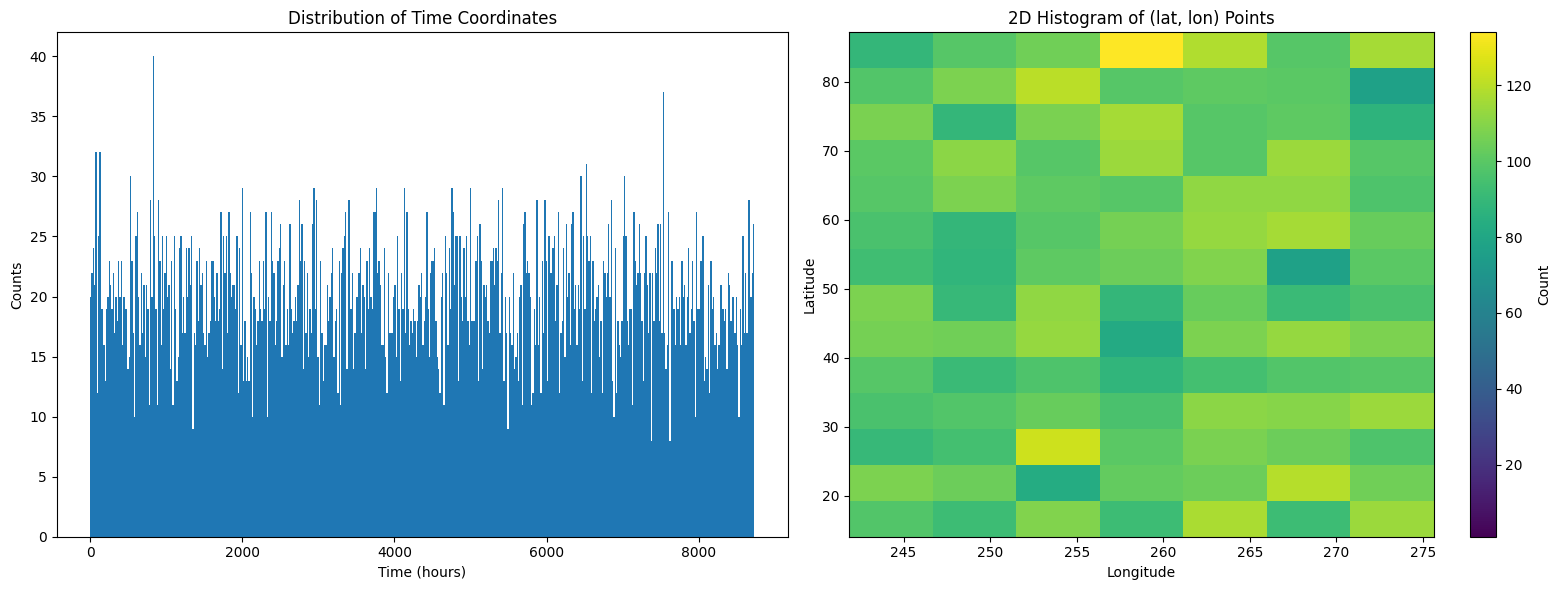

In [15]:
rand_coords = X_train.detach().cpu().numpy()
plot_coords_dist(rand_coords)

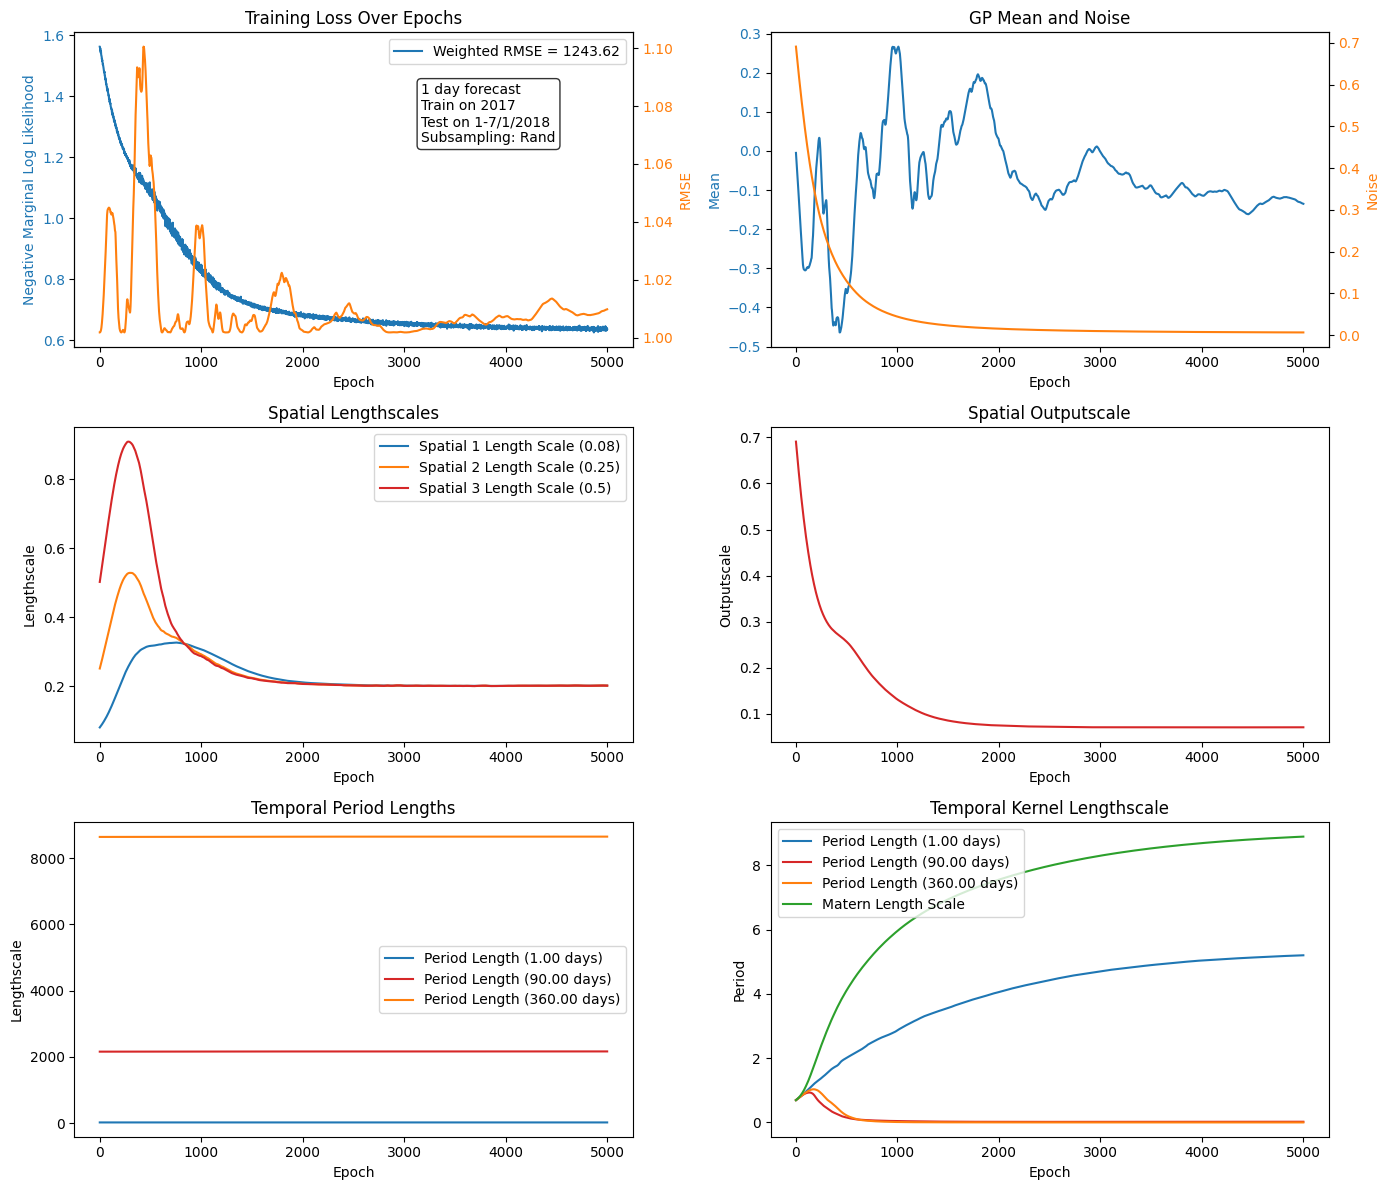

In [16]:
plot_modelparams(hyperparams_track, wrmse, spatial_lengths, period_lengths)

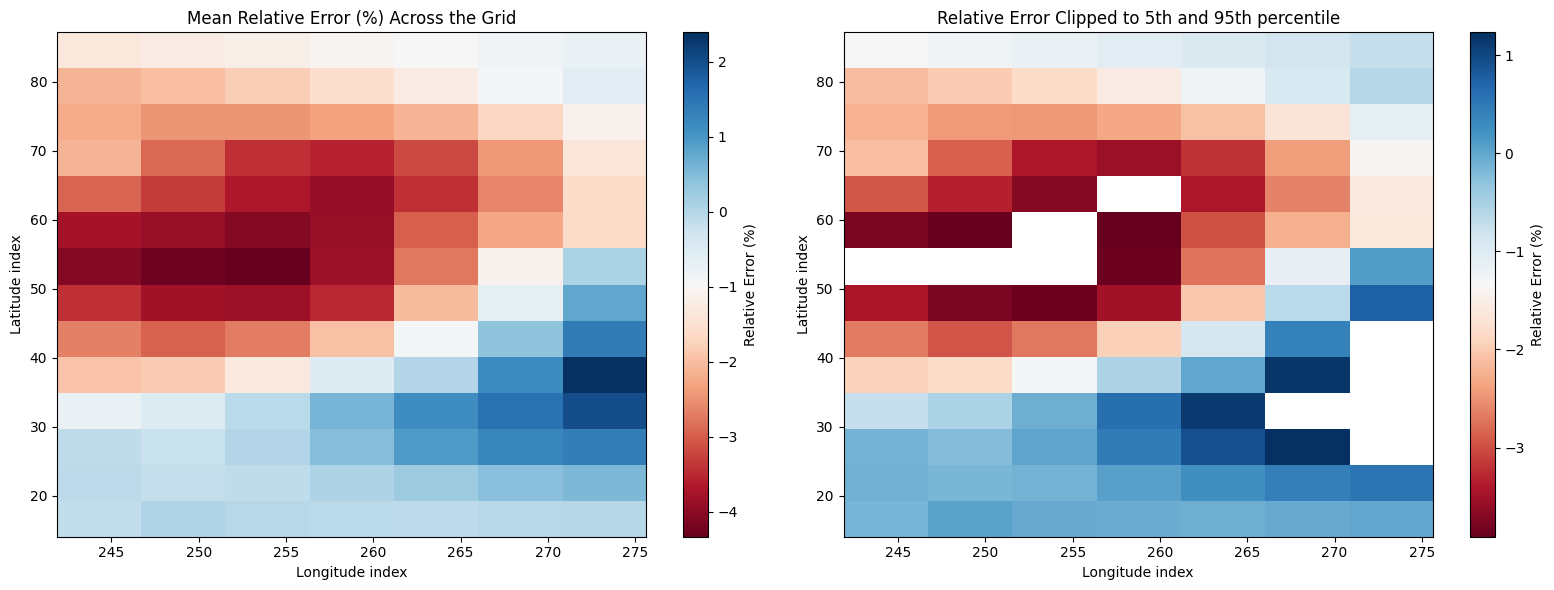

In [17]:
relative_error = (Y_pred_actual - Y_test_actual) / Y_test_actual * 100 
relative_error_mean = plot_relative_err(lat, lon, relative_error)

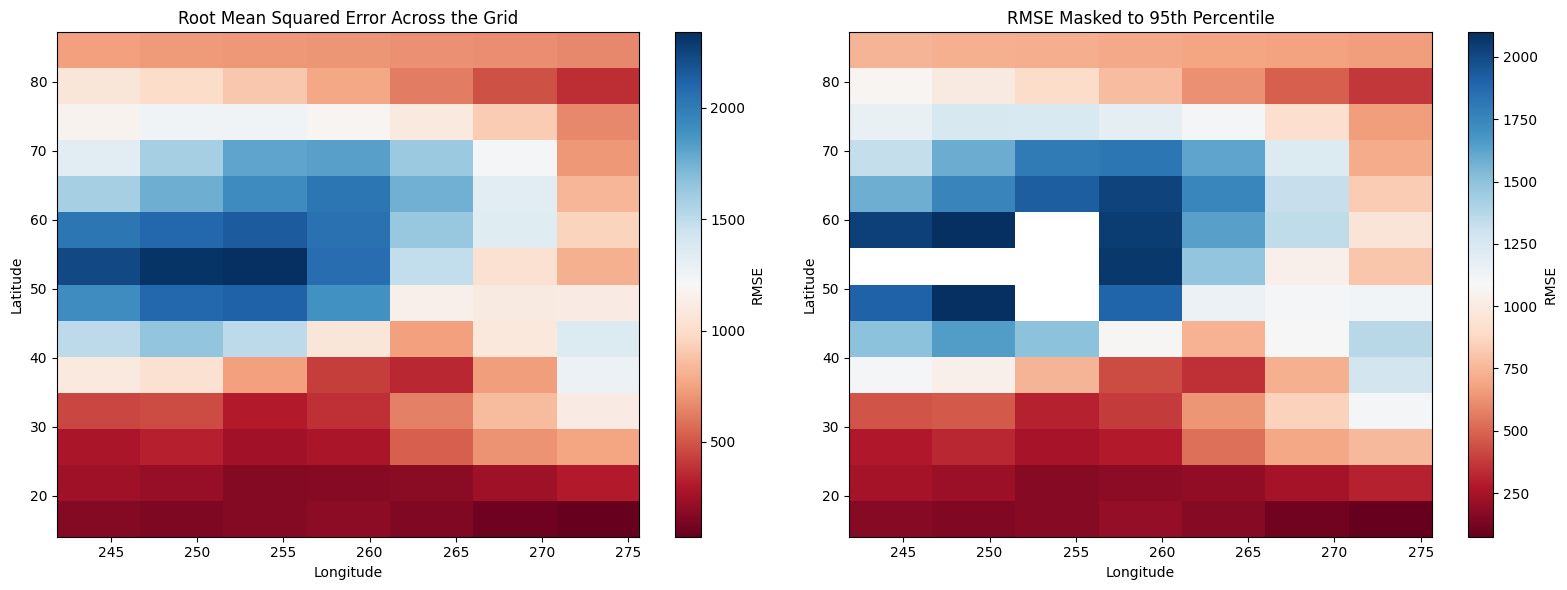

In [18]:
rmse_error = np.sqrt((Y_pred_actual - Y_test_actual)**2)
rmse_error_mean = plot_rmse(lat, lon, rmse_error)

In [19]:
#relative_error_mean = relative_error_mean.values
#rmse_error_mean = rmse_error_mean.values

In [20]:
max_idx = np.argmax(relative_error_mean)
min_idx = np.argmin(relative_error_mean)
best_idx = np.argmin(np.abs(relative_error_mean))

flat_max_idx = np.unravel_index(max_idx, relative_error_mean.shape)
flat_min_idx = np.unravel_index(min_idx, relative_error_mean.shape)
flat_best_idx = np.unravel_index(best_idx, relative_error_mean.shape)

max_err = relative_error_mean[flat_max_idx[0],flat_max_idx[1]]
min_err = relative_error_mean[flat_min_idx[0],flat_min_idx[1]]
best_err = relative_error_mean[flat_best_idx[0],flat_best_idx[1]]

print(f"Highest relative error: ({int(flat_max_idx[0])},{int(flat_max_idx[1])}), with relative error in percentage: {max_err:.3f}")
print(f"Lowest relative error: ({int(flat_min_idx[0])},{int(flat_min_idx[1])}), with relative error in percentage: {min_err:.3f}")
print(f"Smallest relative error: ({int(flat_best_idx[0])},{int(flat_best_idx[1])}), with relative error in percentage: {best_err:.3f}")

Highest relative error: (4,6), with relative error in percentage: 2.390
Lowest relative error: (7,2), with relative error in percentage: -4.331
Smallest relative error: (4,4), with relative error in percentage: 0.004


In [21]:
# Best and worst location based on rmse
rmse_max_idx = np.argmax(rmse_error_mean)
rmse_min_idx = np.argmin(rmse_error_mean)

flat_rmse_max_idx = np.unravel_index(rmse_max_idx, rmse_error_mean.shape)
flat_rmse_min_idx = np.unravel_index(rmse_min_idx, rmse_error_mean.shape)

rmse_max_err = rmse_error_mean[flat_rmse_max_idx[0],flat_rmse_max_idx[1]]
rmse_min_err = rmse_error_mean[flat_rmse_min_idx[0],flat_rmse_min_idx[1]]

print(f"Highest RMSE: ({int(flat_rmse_max_idx[0])},{int(flat_rmse_max_idx[1])}), with value: {rmse_max_err:.3f}")
print(f"Lowest RMSE: ({int(flat_rmse_min_idx[0])},{int(flat_rmse_min_idx[1])}), with value: {rmse_min_err:.3f}")

Highest RMSE: (7,2), with value: 2337.868
Lowest RMSE: (0,6), with value: 74.922


## Observing how the individual point performs

In [22]:
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_train = model(X_train)
    train_mean = pred_train.mean  
    train_std = pred_train.stddev  

sorted_idx = torch.argsort(X_train[:,3])

train_mean = train_mean[sorted_idx].detach().cpu().numpy()
train_std = train_std[sorted_idx].detach().cpu().numpy()
Y_train = Y_train[sorted_idx].detach().cpu().numpy()

/home/syw24/miniforge3/envs/hartree/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


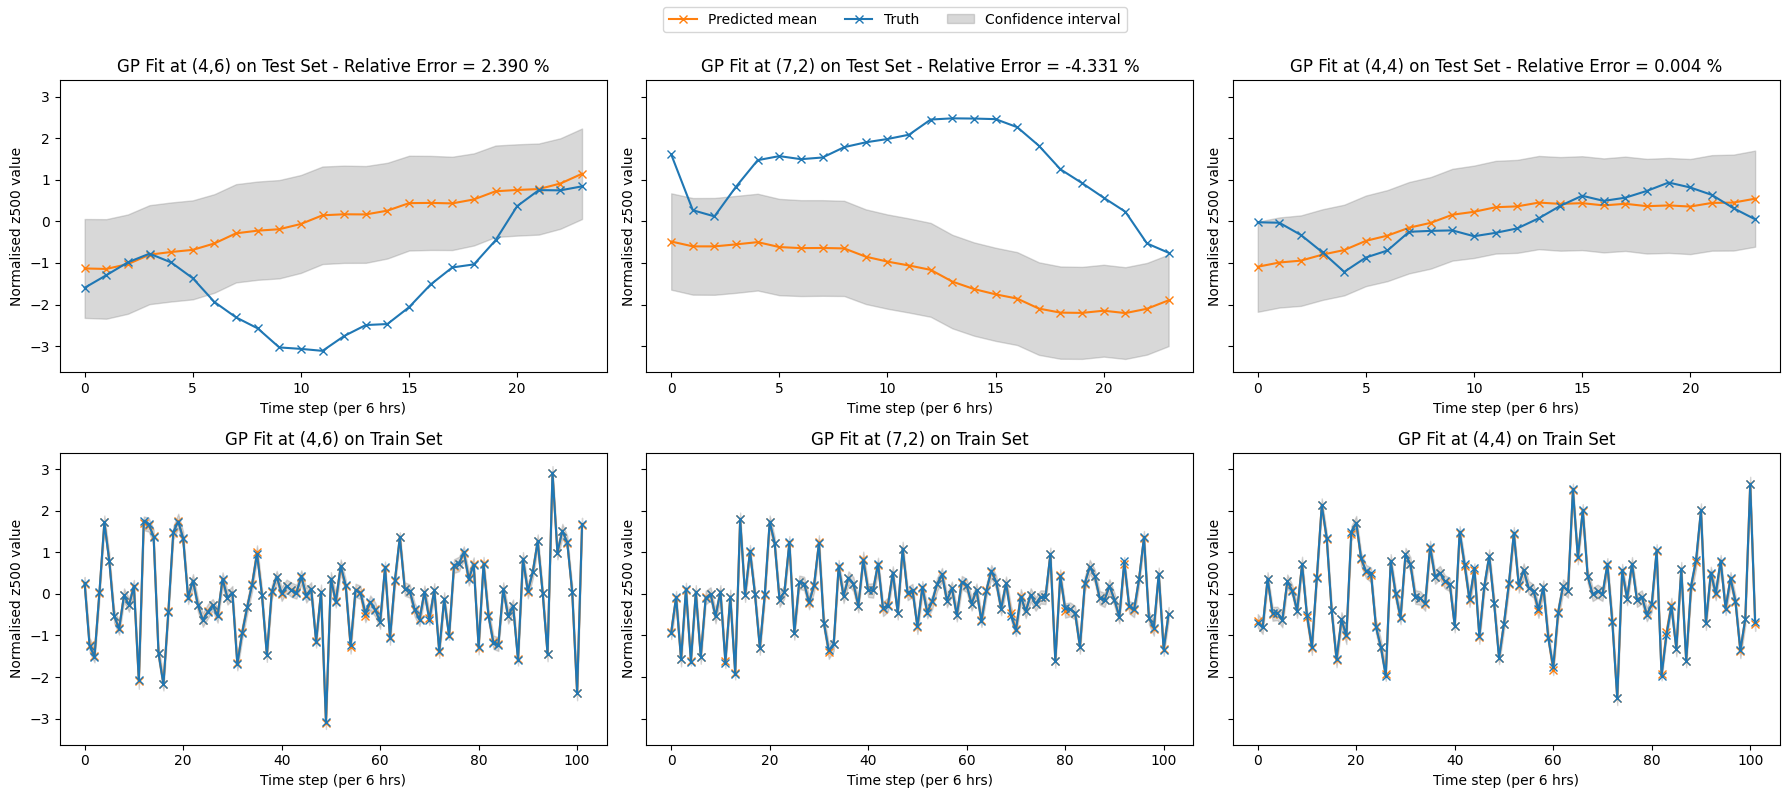

In [23]:
idx = [max_idx, min_idx, best_idx]
val = [max_err, min_err, best_err]
plot_relative_err_posterior(idx, val, time_subsample, relative_error_mean, Y_pred, Y_test, Y_std, train_mean, train_std, Y_train)

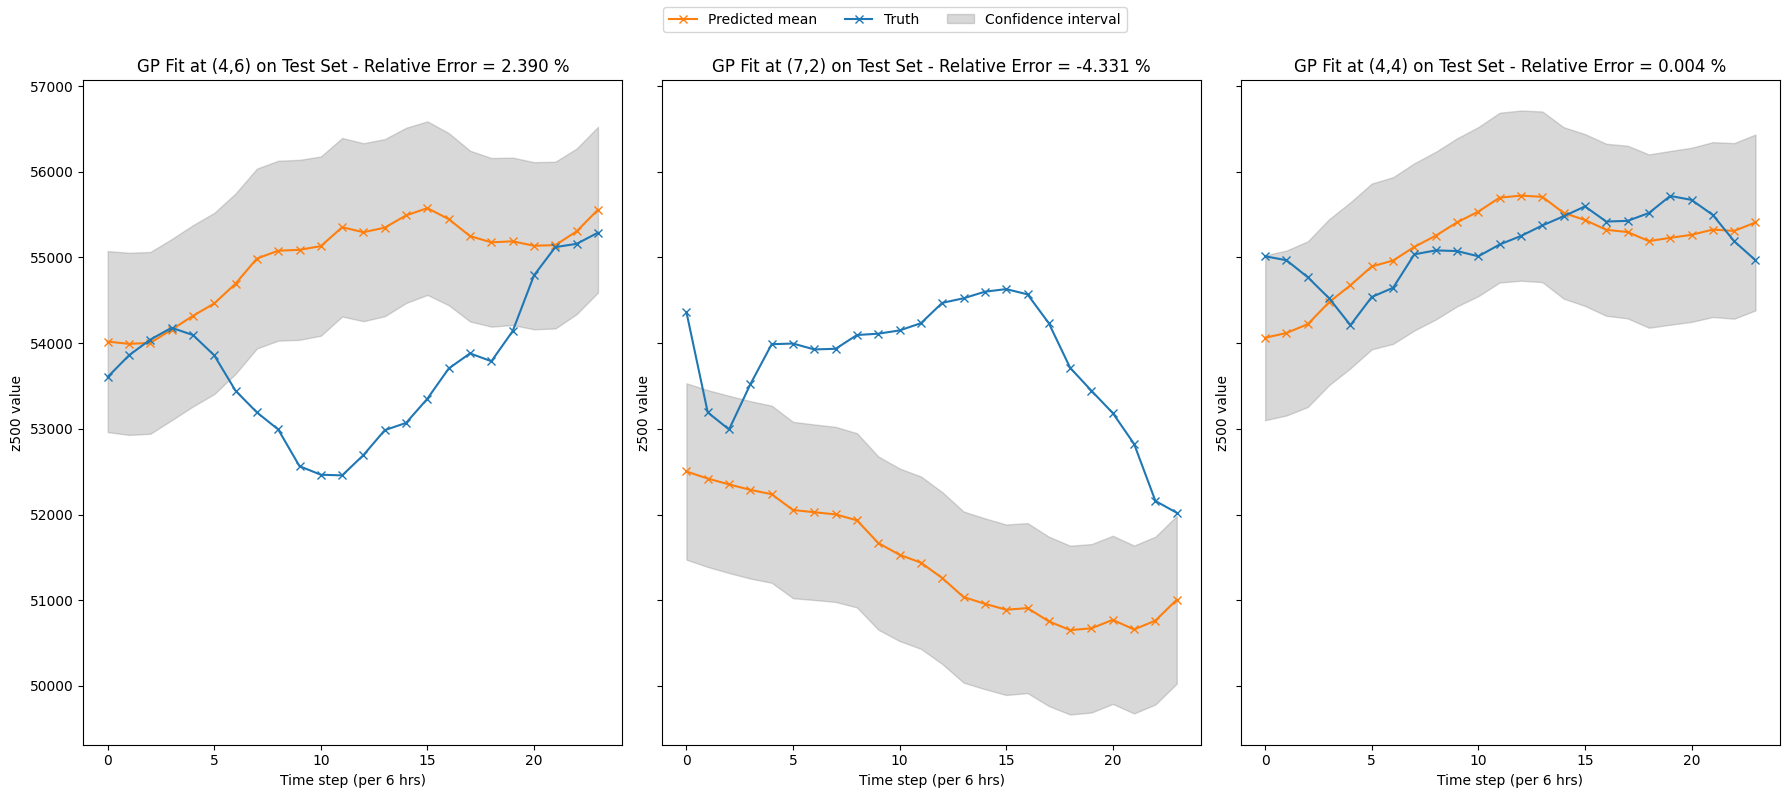

In [24]:
nlat = relative_error_mean.shape[0]
nlon = relative_error_mean.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=False, sharey=True)

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[i]  

    pred_vals = Y_pred_actual.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test_actual.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)] * data_std.values

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - Relative Error = {val[i]:.3f} %")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 

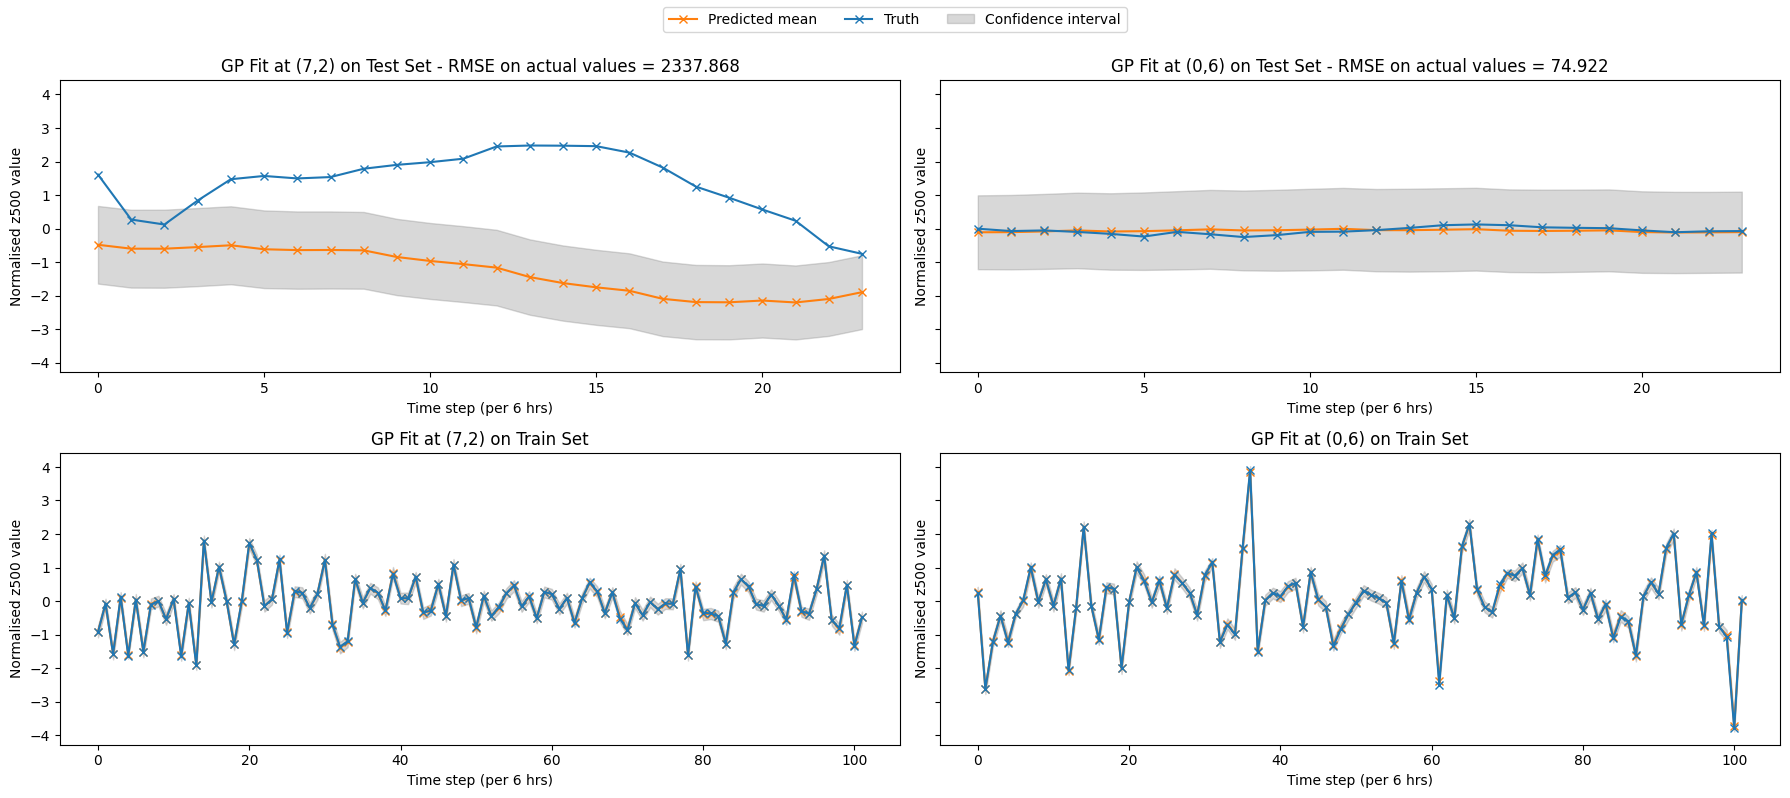

In [25]:
idx = [rmse_max_idx, rmse_min_idx]
val = [rmse_max_err, rmse_min_err]
plot_rmse_posterior(idx, val, time_subsample, rmse_error_mean, Y_pred, Y_test, Y_std, train_mean, train_std, Y_train)

In [26]:
#!mkdir "plots/5.625deg/z500/Train (2017), test (2018_1_7)/ExactGP/lat_18-32_lon_5-8-3matern(0.04,0.08,0.5)+1matern+3periodic(ln2,24,24*3*30,24*12*30)"
#!mv tmp/* "plots/5.625deg/z500/Train (2017), test (2018_1_7)/ExactGP/lat_18-32_lon_5-8-3matern(0.04,0.08,0.5)+1matern+3periodic(ln2,24,24*3*30,24*12*30)"